In [ ]:
mport pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

%matplotlib inline

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ecommerce_customer_data_large.csv to ecommerce_customer_data_large.csv


In [ ]:
import pandas as pd

df = pd.read_csv("ecommerce_customer_data_large.csv")

In [ ]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,202618.000000,250000.000000,250000.00000
mean,25017.632092,254.742724,3.004936,2725.385196,43.798276,0.500824,43.798276,0.20052
std,14412.515718,141.738104,1.414737,1442.576095,15.364915,0.500001,15.364915,0.40039
min,1.000000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.00000
25%,12590.000000,132.000000,2.000000,1476.000000,30.000000,0.000000,30.000000,0.00000
50%,25011.000000,255.000000,3.000000,2725.000000,44.000000,1.000000,44.000000,0.00000
75%,37441.250000,377.000000,4.000000,3975.000000,57.000000,1.000000,57.000000,0.00000
max,50000.000000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.00000


In [ ]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

In [ ]:
df['Spending'] = df['Product Price'] * df['Quantity']

In [ ]:
df[['Product Price', 'Quantity', 'Spending']].head()

,Product Price,Quantity,Spending
0,177,1,177
1,174,3,522
2,413,1,413
3,396,3,1188
4,259,4,1036


In [ ]:
snapshot_date = df['Purchase Date'].max() + pd.Timedelta(days=1)

print(snapshot_date)

2023-09-14 18:42:49


In [ ]:
rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (snapshot_date - x.max()).days,
    'Customer ID': 'count',
    'Total Purchase Amount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
1,289,3,6290
2,73,6,16481
3,223,4,9423
4,442,5,7826
5,425,5,9769


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [ ]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
1,289,3,6290,0
2,73,6,16481,3
3,223,4,9423,0
4,442,5,7826,0
5,425,5,9769,0


In [ ]:
rfm['Cluster'].value_counts()

,count
Cluster,
3,18552
0,15697
1,7762
2,7650


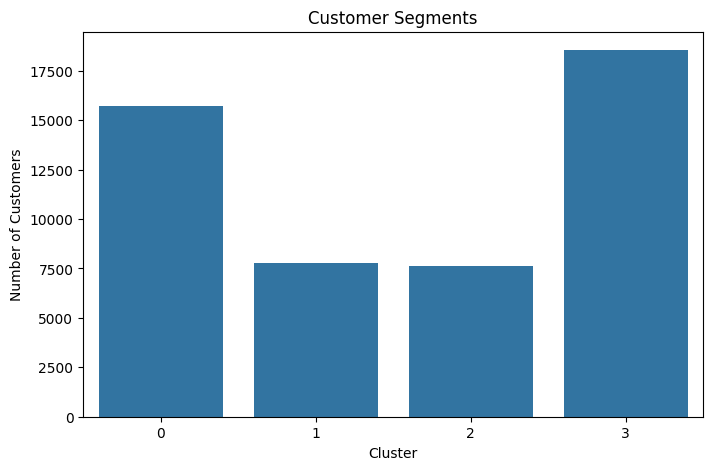

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='Cluster', data=rfm)
plt.title("Customer Segments")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
segment_profile = rfm.groupby('Cluster').mean()

segment_profile

,Recency,Frequency,Monetary
Cluster,,,
0,196.303943,3.420781,8540.961840
1,138.535687,8.536975,24754.201881
2,721.101699,2.924314,7797.505752
3,180.827512,5.803633,15927.435694


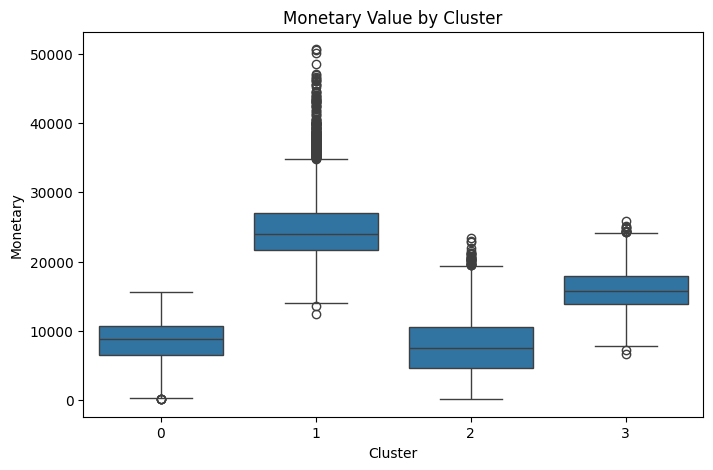

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Cluster', y='Monetary', data=rfm)
plt.title("Monetary Value by Cluster")
plt.show()

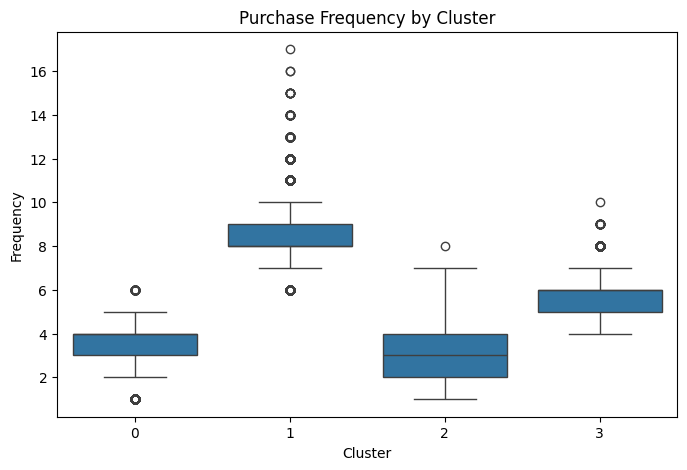

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Cluster', y='Frequency', data=rfm)
plt.title("Purchase Frequency by Cluster")
plt.show()

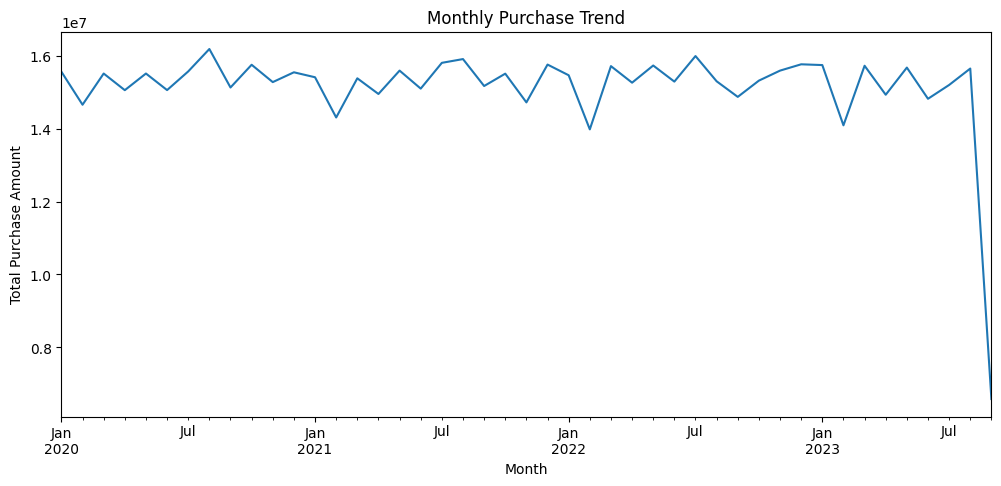

In [ ]:
df['Month'] = df['Purchase Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Total Purchase Amount'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title("Monthly Purchase Trend")
plt.xlabel("Month")
plt.ylabel("Total Purchase Amount")
plt.show()

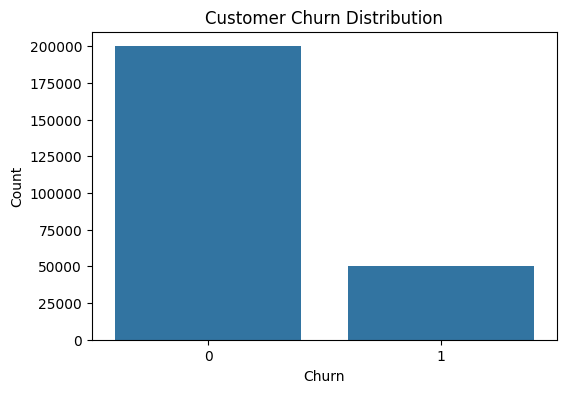

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

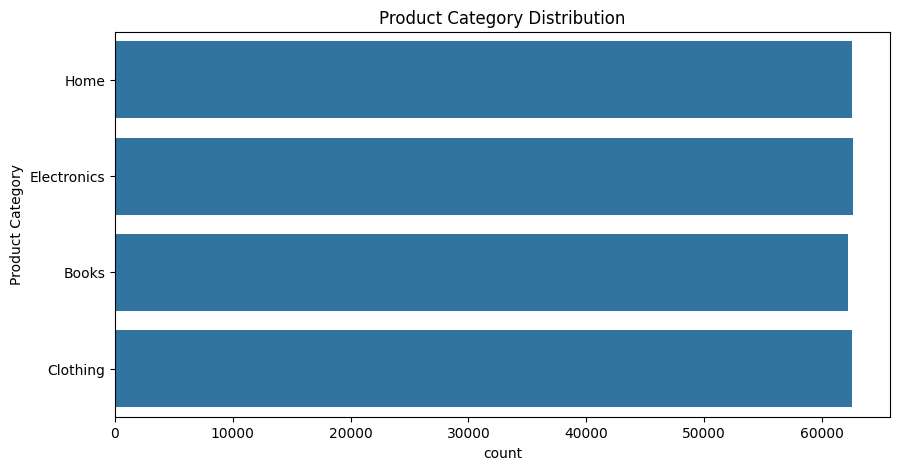

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(y='Product Category', data=df)
plt.title("Product Category Distribution")
plt.show()

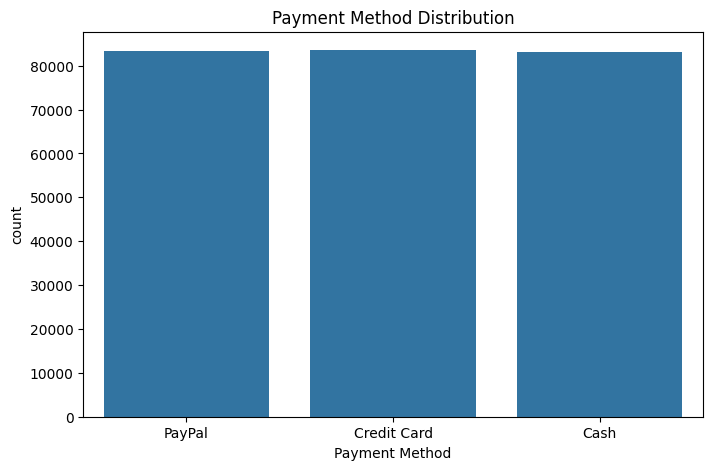

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Payment Method', data=df)
plt.title("Payment Method Distribution")
plt.show()

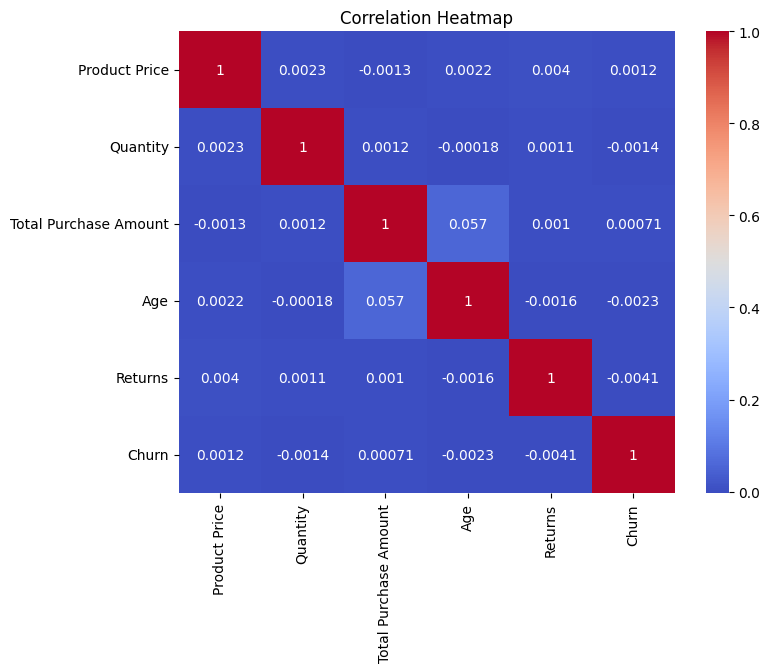

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Product Price','Quantity','Total Purchase Amount','Age','Returns','Churn']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# Customer Behavior Analysis

## Objective
Analyze customer transactions and behavior to identify customer segments, purchase patterns, and churn risks using RFM Analysis and K-Means Clustering.


## Dataset

The dataset used for this project is **ecommerce_customer_data_large.csv**.

It contains customer purchase history, product information, payment methods, customer demographics, and churn details.

### Features
- Customer ID
- Purchase Date
- Product Category
- Product Price
- Quantity
- Total Purchase Amount
- Payment Method
- Customer Age
- Gender
- Returns
- Churn


## Data Cleaning

Before performing the analysis, the dataset was cleaned to ensure data quality.

The following preprocessing steps were performed:

- Checked for missing values.
- Removed duplicate records.
- Converted the **Purchase Date** column into datetime format.
- Verified data types for all columns.


## Feature Engineering

Feature engineering was performed to create meaningful variables for customer analysis.

The following features were used:

- Created a **Spending** column by multiplying Product Price and Quantity.
- Calculated **Recency**, **Frequency**, and **Monetary (RFM)** values for each customer.
- These features were used as input for customer segmentation using K-Means clustering.


## RFM Analysis

RFM (Recency, Frequency, Monetary) analysis was used to measure customer purchasing behavior.

- **Recency (R):** Number of days since the customer's last purchase.
- **Frequency (F):** Number of purchases made by the customer.
- **Monetary (M):** Total amount spent by the customer.

These three metrics help identify valuable customers and understand customer behavior.


## Customer Segmentation using K-Means Clustering

K-Means Clustering was applied to the standardized RFM data to group customers based on their purchasing behavior.

The customers were divided into four clusters, where each cluster represents a group with similar buying patterns.

This segmentation helps businesses understand customer behavior and develop targeted marketing strategies for different customer groups.

## Visualizations

Several visualizations were created to understand customer behavior and purchasing patterns.

The visualizations include:

- Customer Segment Distribution
- Monetary Value by Cluster
- Purchase Frequency by Cluster
- Monthly Purchase Trend
- Customer Churn Distribution
- Product Category Distribution
- Payment Method Distribution
- Correlation Heatmap

These charts provide valuable insights into customer spending habits, purchase frequency, product preferences, and churn behavior.


## Key Findings

The analysis of customer behavior revealed the following insights:

1. Customers were successfully segmented into four groups based on their purchasing behavior using RFM Analysis and K-Means Clustering.

2. Some customer segments showed higher purchase frequency and spending, indicating loyal and high-value customers.

3. Monthly purchase trends highlighted variations in customer buying activity over time.

4. The churn analysis identified customers who are at risk of leaving, helping the business focus on retention strategies.

5. Product category preferences and payment methods differed among customers, providing opportunities for targeted marketing.


## Business Recommendations

Based on the customer behavior analysis, the following recommendations are suggested for Alfido Tech:

1. Introduce loyalty programs and exclusive rewards for high-value customers to increase customer retention.

2. Re-engage customers who are at risk of churn through personalized email campaigns, discounts, and special offers.

3. Recommend products based on customers' previous purchase history to encourage repeat purchases.

4. Develop targeted marketing campaigns for different customer segments instead of using the same strategy for all customers.

5. Continuously monitor customer behavior and update customer segments regularly to improve engagement and reduce churn.


## Conclusion

This project analyzed customer behavior using data cleaning, feature engineering, RFM analysis, and K-Means clustering.

The analysis successfully identified different customer segments based on purchasing behavior, spending patterns, and purchase frequency. Visualizations provided insights into customer trends, product preferences, payment methods, and churn risk.

The findings and recommendations can help Alfido Tech improve customer engagement, increase retention, optimize marketing strategies, and enhance overall business performance.
